# 🛒 Product Return Risk Prediction
### Binary Classification: Predict `high_return_risk` (0 = No, 1 = Yes)
**Fixes Applied:**
- ✅ Separate LabelEncoder per column
- ✅ Correct scoring metric (`accuracy` instead of `neg_mean_squared_error`)
- ✅ StandardScaler applied for Logistic Regression
- ✅ Better hyperparameter grids
- ✅ Added Random Forest for comparison

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully')

All libraries loaded successfully


## 2. Load Data

In [2]:
df = pd.read_csv('C:/Users/Ekangsh/OneDrive/Desktop/Export_Product_Return_Data.csv')
print('Shape:', df.shape)
df.head()

Shape: (5000, 11)


,Unnamed: 0,Age,Gender,State,Category,Brand,Quantity,Price,Discount,Product Rating,high_return_risk
0,4/11/2025 21:36,58,Female,Haryana,Shirts,Nike,5,409,30,1.0,Yes
1,4/11/2025 21:36,29,Male,Uttar Pradesh,Sleepwear,Nike,3,700,25,1.0,Yes
2,4/11/2025 21:36,32,Female,Manipur,Jeans,Zudio,2,898,20,3.0,No
3,4/11/2025 21:36,53,Male,Arunachal Pradesh,Jackets,Zudio,6,607,10,3.5,Yes
4,4/11/2025 21:36,25,Female,Goa,Jackets,Adidas,5,568,10,1.0,No


## 3. Exploratory Data Analysis (EDA)

In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5000 non-null   object 
 1   Age               5000 non-null   int64  
 2   Gender            5000 non-null   object 
 3   State             5000 non-null   object 
 4   Category          5000 non-null   object 
 5   Brand             5000 non-null   object 
 6   Quantity          5000 non-null   int64  
 7   Price             5000 non-null   int64  
 8   Discount          5000 non-null   int64  
 9   Product Rating    5000 non-null   float64
 10  high_return_risk  5000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 429.8+ KB


In [4]:

print('Null values per column:')
df.isnull().sum()

Null values per column:


Unnamed: 0          0
Age                 0
Gender              0
State               0
Category            0
Brand               0
Quantity            0
Price               0
Discount            0
Product Rating      0
high_return_risk    0
dtype: int64

In [5]:

print('Top Categories:')
df['Category'].value_counts().head(10)

Top Categories:


Category
Skirts         364
Sleepwear      358
Dresses        357
T-shirts       345
Formal Wear    342
Ethnic Wear    338
Jeans          336
Suits          332
Shorts         329
Trousers       329
Name: count, dtype: int64

Target Distribution:
high_return_risk
Yes    2546
No     2454
Name: count, dtype: int64


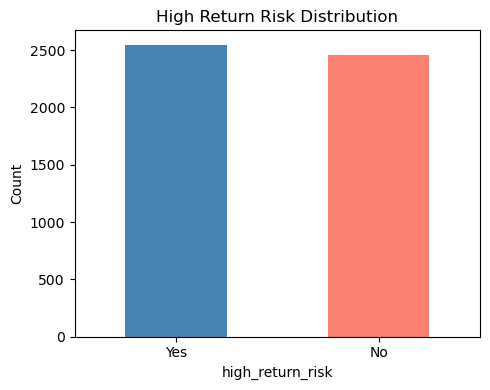

In [6]:

print('Target Distribution:')
print(df['high_return_risk'].value_counts())

plt.figure(figsize=(5, 4))
df['high_return_risk'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('High Return Risk Distribution')
plt.xlabel('high_return_risk')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

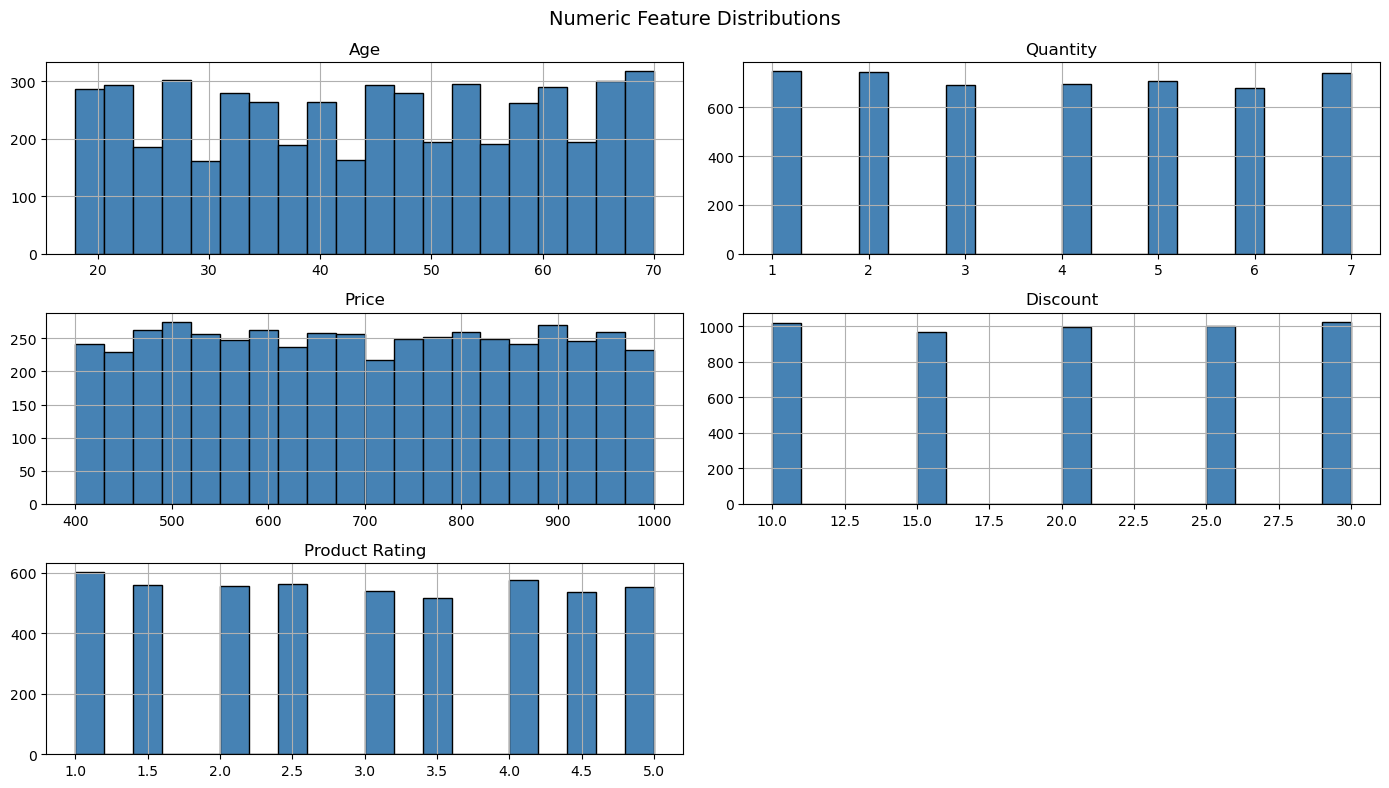

In [7]:
# Numeric feature distributions
num_cols = ['Age', 'Quantity', 'Price', 'Discount', 'Product Rating']
df[num_cols].hist(bins=20, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle('Numeric Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Preprocessing
> **Fix:** Using a **separate LabelEncoder per column** to avoid mapping corruption.

In [8]:
# Drop unnecessary column
df.drop(['Unnamed: 0'], axis=1, inplace=True)

# Encode categorical features — one encoder per column
cat_cols = ['Category', 'State', 'Brand', 'Gender']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le   # save encoder if needed for inverse_transform later
    print(f'{col}: {le.classes_[:5]} → encoded')

# Encode target separately
le_target = LabelEncoder()
df['high_return_risk'] = le_target.fit_transform(df['high_return_risk'])
print(f'\nTarget classes: {le_target.classes_} → {le_target.transform(le_target.classes_)}')

df.head()

Category: ['Activewear' 'Dresses' 'Ethnic Wear' 'Formal Wear' 'Jackets'] → encoded
State: ['Andhra Pradesh' 'Arunachal Pradesh' 'Assam' 'Bihar' 'Chhattisgarh'] → encoded
Brand: ['Adidas' 'H&M' "Levie's" 'Nike' 'Pantaloons'] → encoded
Gender: ['Female' 'Male'] → encoded

Target classes: ['No' 'Yes'] → [0 1]


,Age,Gender,State,Category,Brand,Quantity,Price,Discount,Product Rating,high_return_risk
0,58,0,7,6,3,5,409,30,1.0,1
1,29,1,25,9,3,3,700,25,1.0,1
2,32,0,14,5,7,2,898,20,3.0,0
3,53,1,1,4,7,6,607,10,3.5,1
4,25,0,5,4,0,5,568,10,1.0,0


## 5. Feature & Target Split

In [9]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature columns:', list(X.columns))
X.head()

Features shape: (5000, 9)
Target shape: (5000,)

Feature columns: ['Age', 'Gender', 'State', 'Category', 'Brand', 'Quantity', 'Price', 'Discount', 'Product Rating']


,Age,Gender,State,Category,Brand,Quantity,Price,Discount,Product Rating
0,58,0,7,6,3,5,409,30,1.0
1,29,1,25,9,3,3,700,25,1.0
2,32,0,14,5,7,2,898,20,3.0
3,53,1,1,4,7,6,607,10,3.5
4,25,0,5,4,0,5,568,10,1.0


## 6. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)

Train size: (4000, 9)
Test size:  (1000, 9)


## 7. Feature Scaling
> **Fix:** StandardScaler applied — required for Logistic Regression to converge properly.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # only transform, never fit on test

print('Scaling done ✅')

Scaling done ✅


In [12]:
# StratifiedKFold — shared across all models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 8. Logistic Regression
> **Fix:** scoring=`accuracy`, added `max_iter=1000`, proper solver options.

In [13]:
lr = LogisticRegression(max_iter=1000)

param_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'saga'],
    'random_state': [42]
}

grid_lr = GridSearchCV(
    lr,
    param_lr,
    scoring='accuracy',   # ← FIXED: was neg_mean_squared_error
    cv=skf,
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train_scaled, y_train)

print('\nBest Parameters:', grid_lr.best_params_)
print('Best CV Accuracy:', round(grid_lr.best_score_, 4))

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'random_state': 42, 'solver': 'saga'}
Best CV Accuracy: 0.514


In [14]:
y_pred_lr = grid_lr.predict(X_test_scaled)

print('Logistic Regression Results')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_pred_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Risk', 'High Risk']))

Logistic Regression Results
Test Accuracy : 0.5010
ROC-AUC Score : 0.4985

              precision    recall  f1-score   support

     No Risk       0.49      0.36      0.41       491
   High Risk       0.51      0.64      0.57       509

    accuracy                           0.50      1000
   macro avg       0.50      0.50      0.49      1000
weighted avg       0.50      0.50      0.49      1000



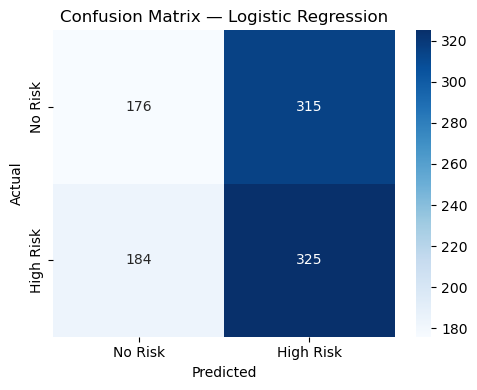

In [15]:
# Confusion Matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Risk', 'High Risk'],
            yticklabels=['No Risk', 'High Risk'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 9. Gradient Boosting Classifier
> **Fix:** scoring=`accuracy`, added `max_depth` tuning.

In [16]:
gb = GradientBoostingClassifier()

param_gb = {
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'random_state': [42]
}

grid_gb = GridSearchCV(
    gb,
    param_gb,
    scoring='accuracy',   # ← FIXED
    cv=skf,
    n_jobs=-1,
    verbose=1
)
grid_gb.fit(X_train, y_train)   # GB does not need scaling

print('\nBest Parameters:', grid_gb.best_params_)
print('Best CV Accuracy:', round(grid_gb.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits



Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'random_state': 42}
Best CV Accuracy: 0.5122


In [17]:
y_pred_gb = grid_gb.predict(X_test)

print('=== Gradient Boosting Results ===')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_pred_gb):.4f}')
print()
print(classification_report(y_test, y_pred_gb, target_names=['No Risk', 'High Risk']))

=== Gradient Boosting Results ===
Test Accuracy : 0.5130
ROC-AUC Score : 0.5109

              precision    recall  f1-score   support

     No Risk       0.51      0.40      0.44       491
   High Risk       0.52      0.63      0.57       509

    accuracy                           0.51      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.51      0.51      0.51      1000



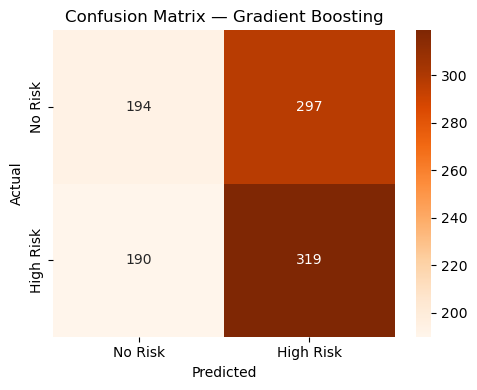

In [18]:
# Confusion Matrix - Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Risk', 'High Risk'],
            yticklabels=['No Risk', 'High Risk'])
plt.title('Confusion Matrix — Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 10. Random Forest Classifier (Bonus)

In [19]:
rf = RandomForestClassifier()

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'random_state': [42]
}

grid_rf = GridSearchCV(
    rf,
    param_rf,
    scoring='accuracy',
    cv=skf,
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

print('\nBest Parameters:', grid_rf.best_params_)
print('Best CV Accuracy:', round(grid_rf.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits



Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200, 'random_state': 42}
Best CV Accuracy: 0.4995


In [20]:
y_pred_rf = grid_rf.predict(X_test)

print('=== Random Forest Results ===')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_pred_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Risk', 'High Risk']))

=== Random Forest Results ===
Test Accuracy : 0.5180
ROC-AUC Score : 0.5156

              precision    recall  f1-score   support

     No Risk       0.51      0.38      0.44       491
   High Risk       0.52      0.65      0.58       509

    accuracy                           0.52      1000
   macro avg       0.52      0.52      0.51      1000
weighted avg       0.52      0.52      0.51      1000



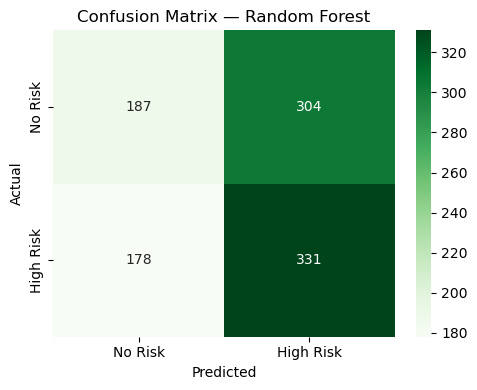

In [21]:
# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Risk', 'High Risk'],
            yticklabels=['No Risk', 'High Risk'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 11. Feature Importance (Gradient Boosting & Random Forest)

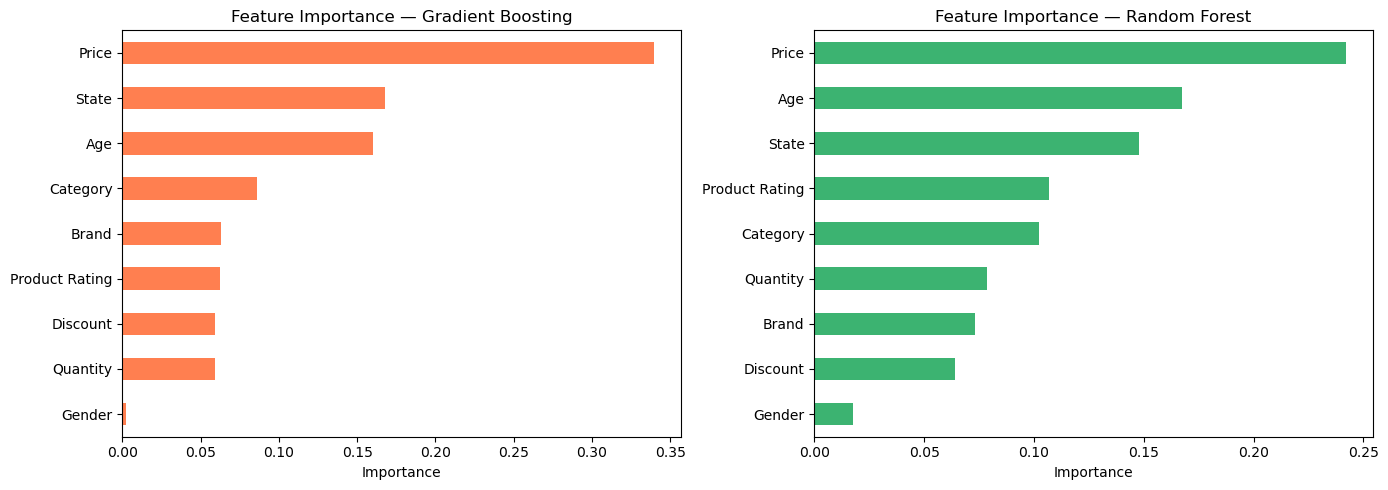

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title, color in zip(
    axes,
    [grid_gb.best_estimator_, grid_rf.best_estimator_],
    ['Gradient Boosting', 'Random Forest'],
    ['coral', 'mediumseagreen']
):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Feature Importance — {title}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 12. Model Comparison Summary

In [23]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gradient Boosting', 'Random Forest'],
    'Test Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_pred_gb),
        roc_auc_score(y_test, y_pred_rf)
    ]
})
results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

              Model  Test Accuracy  ROC-AUC
      Random Forest          0.518 0.515575
  Gradient Boosting          0.513 0.510916
Logistic Regression          0.501 0.498480


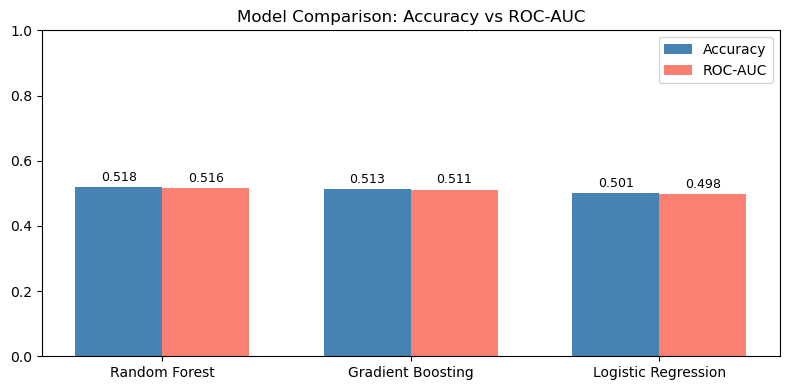

In [24]:
# Visual comparison
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(results))
width = 0.35

bars1 = ax.bar(x - width/2, results['Test Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, results['ROC-AUC'], width, label='ROC-AUC', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylim(0, 1)
ax.set_title('Model Comparison: Accuracy vs ROC-AUC')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()